In [89]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

## Đọc và Khám Phá Dữ Liệu

In [90]:
fp = r"..\data\raw\clickbait_dataset_vietnamese.csv"

df = pd.read_csv(fp)
df.head()

,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label
0,article_0001,https://vnexpress.net/san-bay-vinh-dong-cua-6-...,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,Nghệ AnCảng hàng không Vinh sẽ ngừng hoạt động...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0001_image.png,non-clickbait
1,article_0002,https://vnexpress.net/5-nguoi-thoat-nan-khi-ot...,5 người thoát nạn khi ôtô bị lũ cuốn,Tuyên QuangĐi theo Google Maps song lại được c...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0002_image.png,non-clickbait
2,article_0004,https://vnexpress.net/quy-hoach-9-khu-chuc-nan...,Quy hoạch 9 khu chức năng phía đông TP HCM,9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê d...,Tin tức tổng hợp,2025-06-23T11:56:00+07:00,VnExpress,data/images/article_0004_image.png,non-clickbait
3,article_0006,https://vnexpress.net/tong-bi-thu-trao-quyet-d...,Tổng Bí thư trao quyết định thành lập Cơ quan ...,"Sáng 23/6, Tổng Bí thư Tô Lâm dự và trao quyết...",Tin tức tổng hợp,2025-06-23T11:03:00+07:00,VnExpress,data/images/article_0006_image.png,non-clickbait
4,article_0010,https://vnexpress.net/quoc-hoi-buoc-vao-tuan-l...,Quốc hội bước vào tuần làm việc cuối cùng của ...,"Tuần cuối kỳ họp 9 (23-27/6), Quốc hội sẽ biểu...",Tin tức tổng hợp,2025-06-23T05:00:00+07:00,VnExpress,data/images/article_0010_image.png,non-clickbait


In [91]:
print(f"Có {len(df)} mẫu dữ liệu.\n")
print("Thông tin dataset:")
print(df.info())
print()
print("Thông tin số lượng NaN value:")
print(df.isna().sum())

Có 3414 mẫu dữ liệu.

Thông tin dataset:
<class 'pandas.DataFrame'>
RangeIndex: 3414 entries, 0 to 3413
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                3414 non-null   str  
 1   url               3414 non-null   str  
 2   title             3414 non-null   str  
 3   lead_paragraph    3411 non-null   str  
 4   category          3414 non-null   str  
 5   publish_datetime  3383 non-null   str  
 6   source            3414 non-null   str  
 7   thumbnail_url     3410 non-null   str  
 8   label             3414 non-null   str  
dtypes: str(9)
memory usage: 1.9 MB
None

Thông tin số lượng NaN value:
id                   0
url                  0
title                0
lead_paragraph       3
category             0
publish_datetime    31
source               0
thumbnail_url        4
label                0
dtype: int64


In [92]:
def plot_label_dist(labels, title=""):
    freq = Counter(labels)
    sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')
    plt.title(title)

C:\Users\luann\AppData\Local\Temp\ipykernel_30144\879931907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')


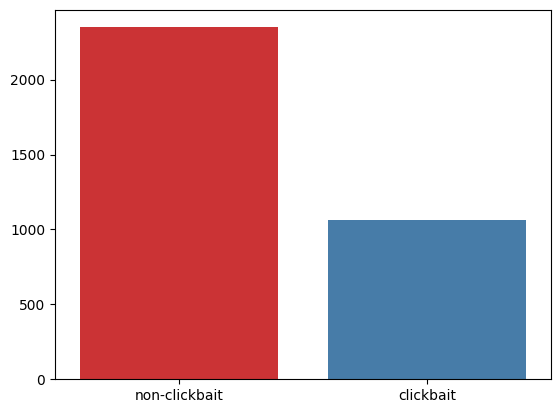

Số lượng nhãn là non-clickbait: 2349
Số lượng nhãn là clickbait: 1065


In [93]:
labels = df["label"].tolist()

plot_label_dist(labels)
plt.show()

print(f"Số lượng nhãn là non-clickbait: {freq["non-clickbait"]}")
print(f"Số lượng nhãn là clickbait: {freq["clickbait"]}")

In [94]:
paths = [r"..\data\raw\train_clickbait.csv", r"..\data\raw\val_clickbait.csv", r"..\data\raw\test_clickbait.csv"]
dfs = []
for p in paths:
    dfs.append(pd.read_csv(p))

C:\Users\luann\AppData\Local\Temp\ipykernel_30144\879931907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')
C:\Users\luann\AppData\Local\Temp\ipykernel_30144\879931907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')
C:\Users\luann\AppData\Local\Temp\ipykernel_30144\879931907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')


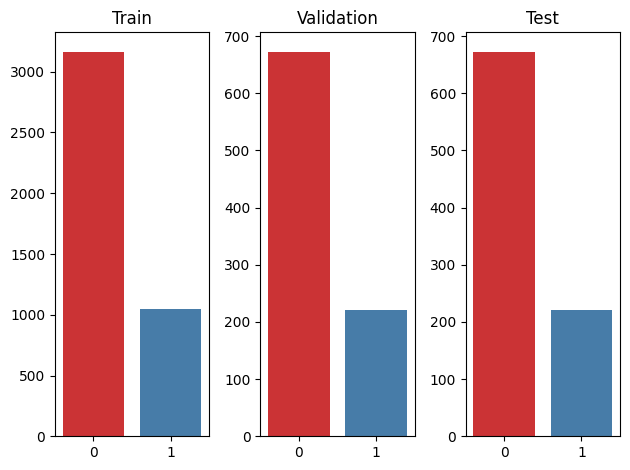

In [95]:
for i, (df, title) in enumerate(zip(dfs, ["Train", "Validation", "Test"]), 1):
    labels = df["final_label"]
    plt.subplot(1, 3, i)
    plot_label_dist(labels, title)
plt.tight_layout()
plt.show()